## 4.4 拉丁超立方设计

实际问题中我们可能需要处理上百个变量,但仅有少数变量会对输出结果产生实质性影响.著名的帕累托原理指出,系统内20%的变量能够解释输出80%的变异.在试验设计相关文献中,该规律被称为效应稀疏原理(吴,滨田,2021,第169页).这种普遍存在的现象会对试验设计带来哪些影响?

考虑包含两个变量,4次试验的设计,对应的极大极小设计与极小极大设计如图4.6所示.该算例中聚类型设计与极小极大设计完全一致.现假设变量$x_{2}$无实际作用,即其对输出的影响可忽略不计.对于左侧设计,相当于在$x_{1}=0$与$x_{1}=1$处各重复开展两次试验;右侧设计则是在$x_{1}=0.25$与$x_{1}=0.75$处重复试验.由于输出不存在测量误差,重复试验会得到完全相同的输出结果.在开展试验前即可预判该情况,意味着这两组重复试验纯粹浪费试验成本.若变量$x_{1}$无关紧要,仅$x_{2}$起作用,也会出现相同问题.这类不理想场景在实际应用中十分常见,我们应当如何规避?

>**图4.6** 4次试验对应的极大极小设计与极小极大设计,以及二者在各坐标轴上的投影.

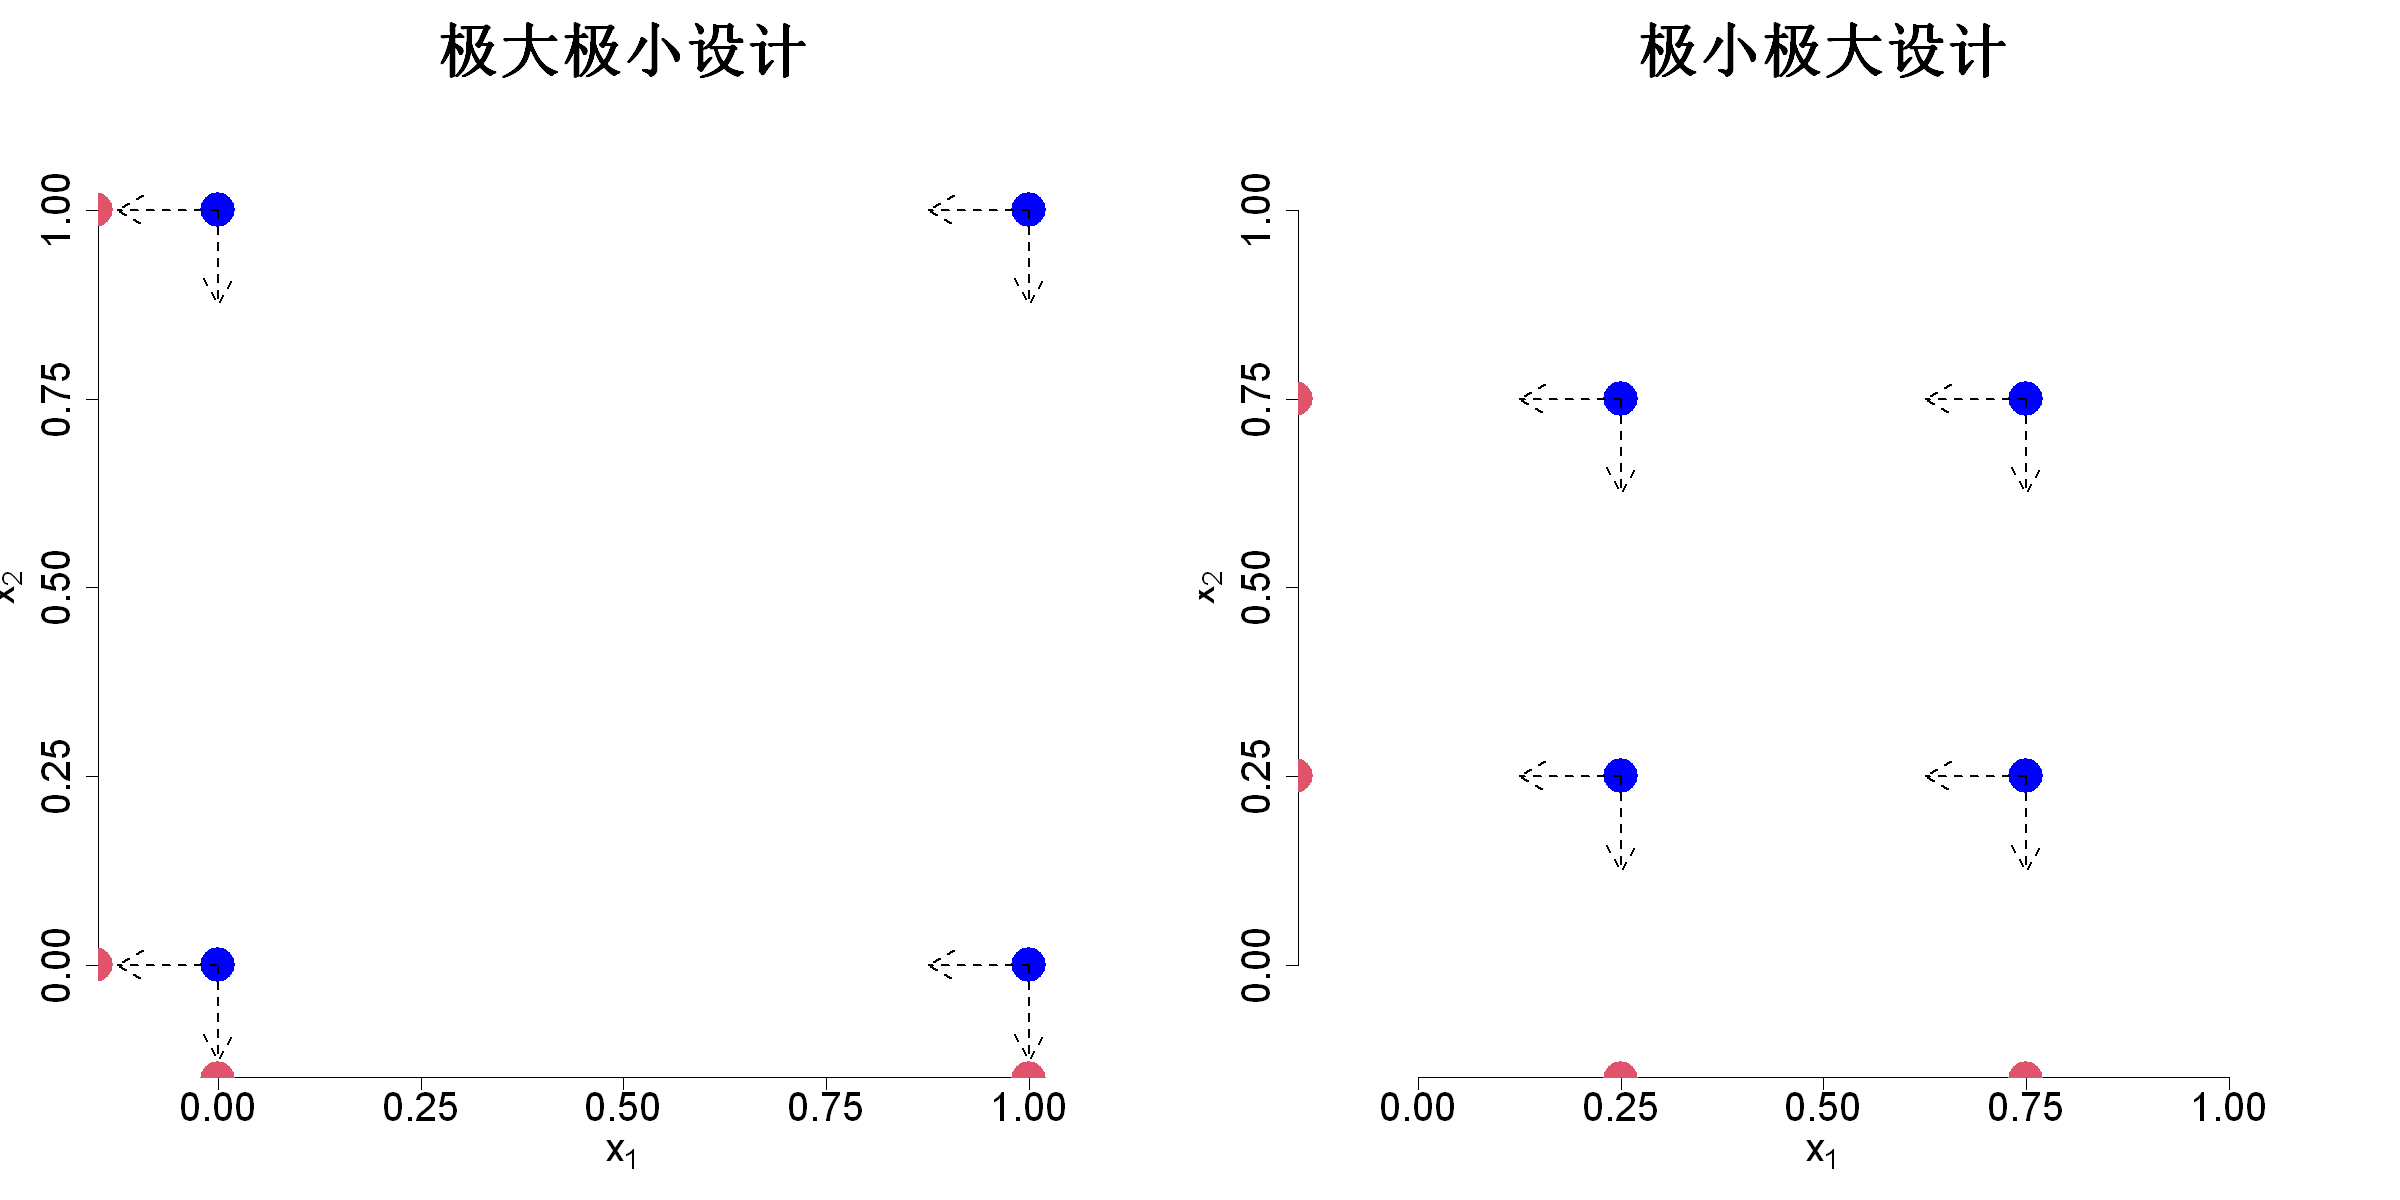

In [2]:
#图4.6

options(repr.plot.width=20,repr.plot.height=10)
par(mfrow=c(1,2))
D=matrix(c(0,0,0,1,1,0,1,1),nrow=4,ncol=2,byrow=TRUE)
plot(D,pch=16,xaxt="n",yaxt="n",cex=4,bty="n",col="blue",xlim=c(-.1,1.1),ylim=c(-.1,1.1),xlab=expression(x[1]),ylab=expression(x[2]),cex.lab=2,main="极大极小设计",cex.main=3)
axis(1,at=seq(0,1,by=.25),cex.axis=2)
axis(2,at=seq(0,1,by=.25),cex.axis=2)
points(cbind(D[,1],-.15),col=2,pch=16,cex=4)
points(cbind(-.15,D[,2]),col=2,pch=16,cex=4)
arrows(0,0,0,-.125,lwd=2,lty=2)
arrows(1,0,1,-.125,lwd=2,lty=2)
arrows(0,1,0,.875,lwd=2,lty=2)
arrows(1,1,1,.875,lwd=2,lty=2)
arrows(0,0,-.125,0,lwd=2,lty=2)
arrows(0,1,-.125,1,lwd=2,lty=2)
arrows(1,0,.875,0,lwd=2,lty=2)
arrows(1,1,.875,1,lwd=2,lty=2)

D=matrix(c(0.25,0.25,.25,.75,.75,.25,.75,.75),nrow=4,ncol=2,byrow=TRUE)
plot(D,pch=16,xaxt="n",yaxt="n",cex=4,bty="n",col="blue",xlim=c(-.1,1.1),ylim=c(-.1,1.1),xlab=expression(x[1]),ylab=expression(x[2]),cex.lab=2,main="极小极大设计",cex.main=3)
axis(1,at=seq(0,1,by=.25),cex.axis=2)
axis(2,at=seq(0,1,by=.25),cex.axis=2)
points(cbind(D[,1],-.15),col=2,pch=16,cex=4)
arrows(.25,.25,.25,.125,lwd=2,lty=2)
arrows(.75,.25,.75,.125,lwd=2,lty=2)
arrows(.25,.75,.25,.625,lwd=2,lty=2)
arrows(.75,.75,.75,.625,lwd=2,lty=2)
points(cbind(-.15,D[,2]),col=2,pch=16,cex=4)
arrows(.25,.25,.125,.25,lwd=2,lty=2)
arrows(.25,.75,.125,.75,lwd=2,lty=2)
arrows(.75,.25,.625,.25,lwd=2,lty=2)
arrows(.75,.75,.625,.75,lwd=2,lty=2)
par(mfrow=c(1,1))

倘若事先已知$x_{2}$无关紧要,则应当针对$x_{1}$采用最优设计安排四次试验;反之同理.该类设计如图4.7左图所示,我们对每个输入变量采用极小极大设计$\{i-0.5\}_{i=1}^{4}$.能够看到,四个设计点在每条坐标轴上的投影,均可为两个变量各自提供四个互不相同的取值.因此,即便试验结束后发现其中某一变量并不重要,该设计依旧能够保持良好效果.

构造具备优良一维投影性质的设计较为简便.将每条坐标轴划分为$n$个等间距区间,随后要求每个区间行与区间列内仅包含一个采样点,即可得到满足投影要求的设计,如图4.7所示.在更高维情形下,第$j$列可按下式生成

$$\left\{\frac{\pi_{j}(i)-.5}{n}\right\}_{i=1}^{n}\tag{4.21}$$

其中$\{\pi_{j}(1),\dots,\pi_{j}(n)\}$是集合$\{1,\dots,n\}$的一组随机置换.这类设计称为拉丁超立方设计(LHD)(麦凯等人,1979).也可以在每个单元格内部对采样点施加随机扰动,对应形式为$\{(\pi_{j}(i)-u_{ij})/n\}_{i=1}^{n}$,其中$u_{ij}\stackrel{\mathrm{i.i.d.}}{\sim}\mathcal{U}(0,1)$,$i=1,\dots,n$,$j=1,\dots,p$.从试验设计角度来看,随机扰动并非必要,本文将采用各个单元格的中心点,也就是令$u_{ij}=0.5$,即式(4.21)的形式.

>**图4.7** 4组拉丁超立方设计,各坐标轴上展示对应投影

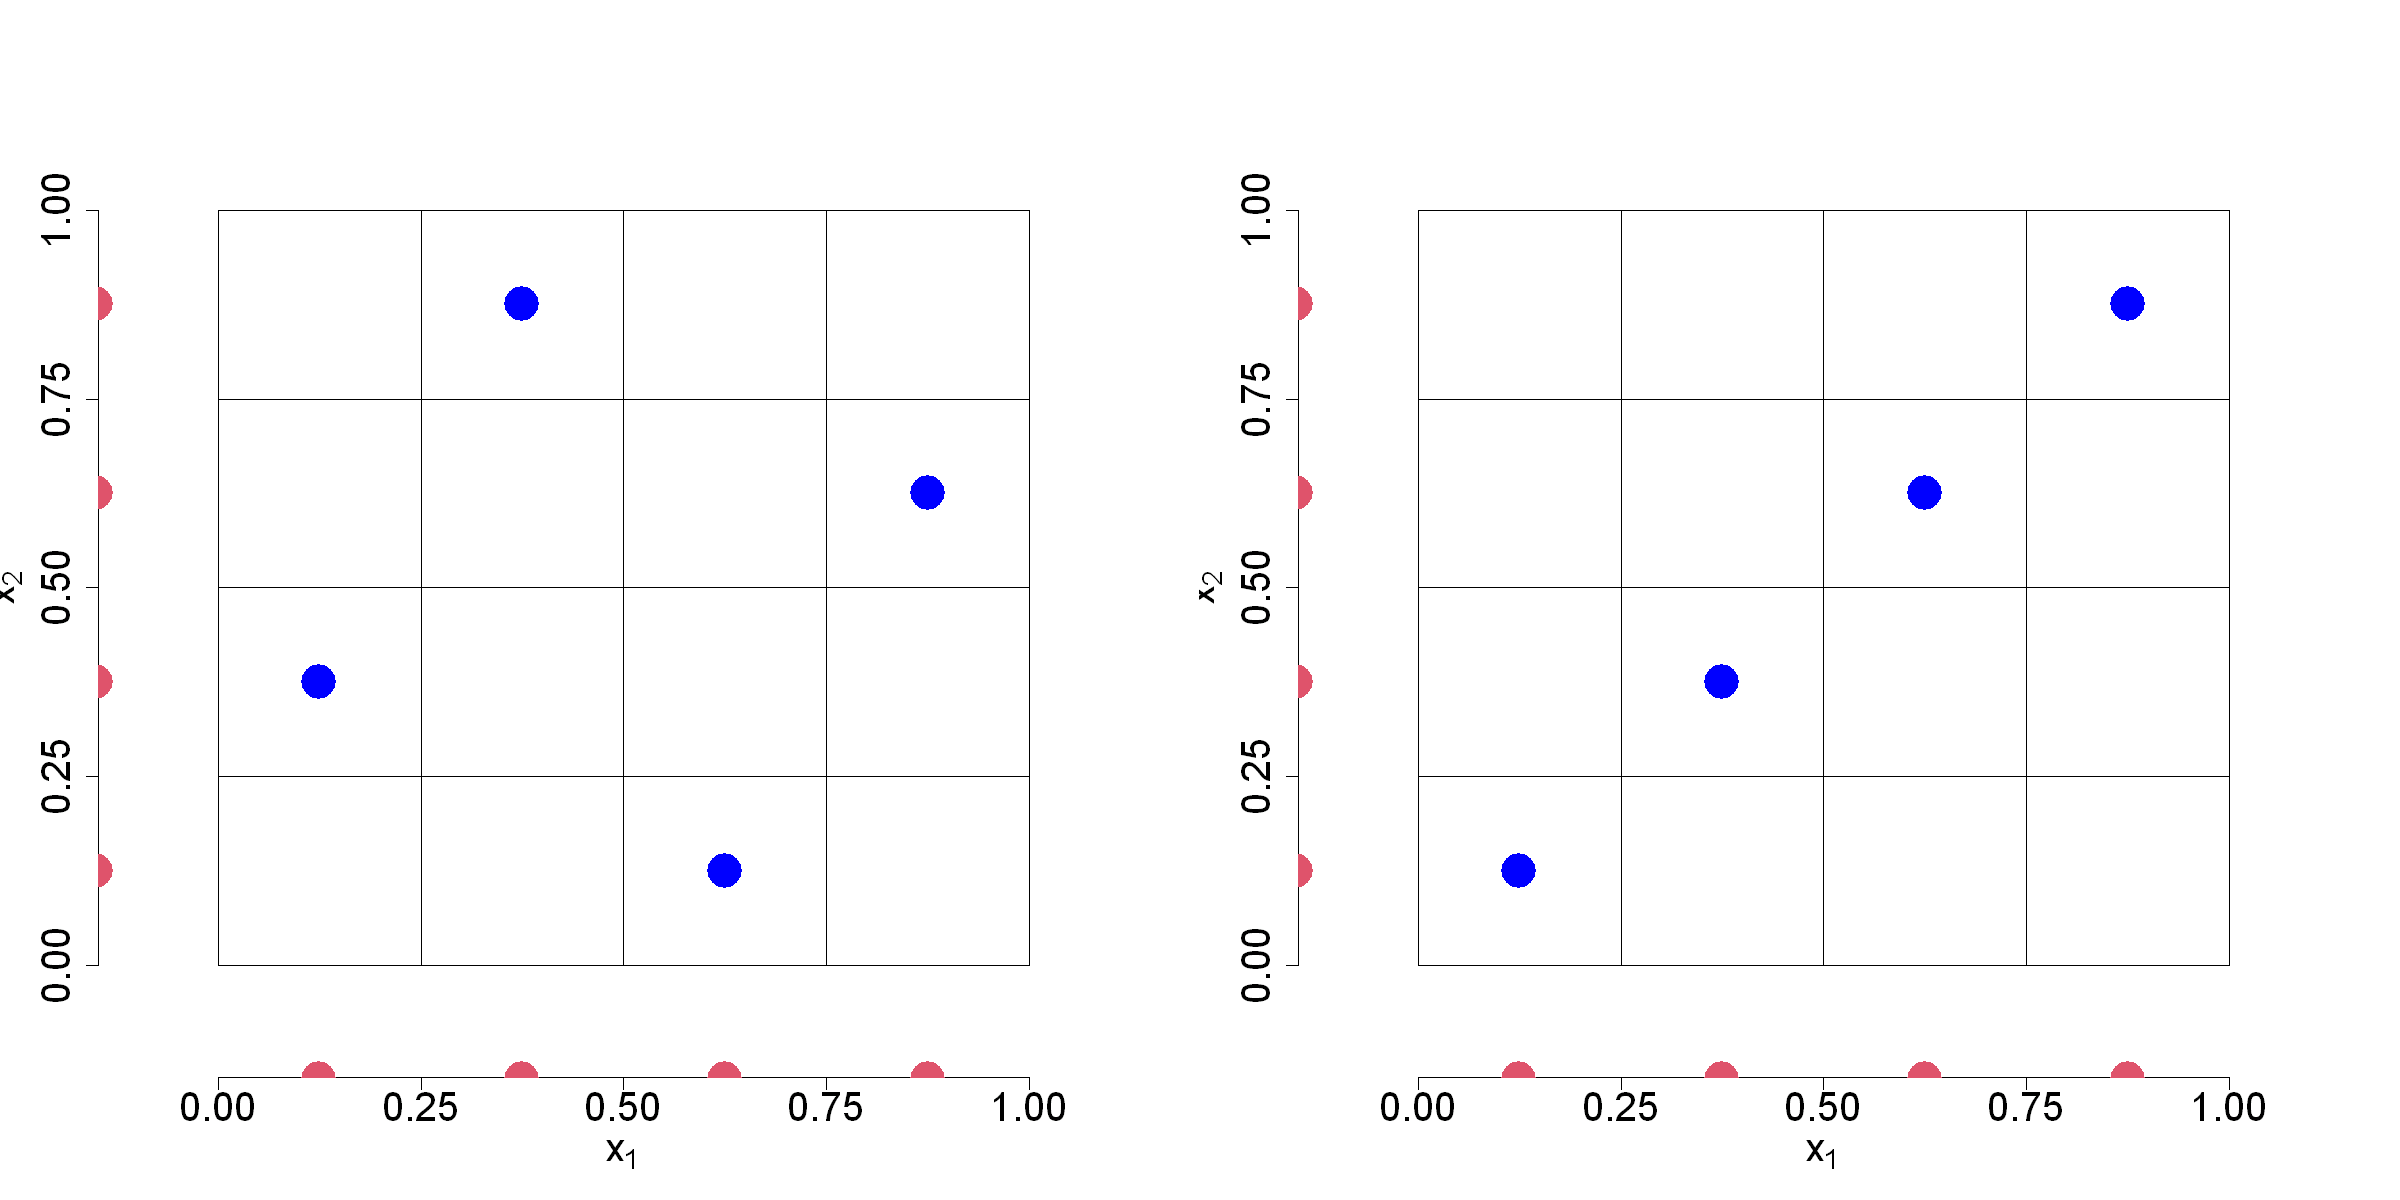

In [2]:
#图4.7

options(repr.plot.width=20,repr.plot.height=10)
par(mfrow=c(1,2))
p=2;n=4
set.seed(1)
library(SFDesign)
D=maximinLHD(n,p)$design
plot(D,pch=16,xaxt="n",yaxt="n",cex=4,bty="n",col="blue",xlim=c(-.1,1.1),ylim=c(-.1,1.1),xlab=expression(x[1]),ylab=expression(x[2]),cex.lab=2)
axis(1,at=seq(0,1,by=.25),cex.axis=2)
axis(2,at=seq(0,1,by=.25),cex.axis=2)
for(i in 1:(n+1))
{
segments((i-1)/n,0,(i-1)/n,1)
segments(0,(i-1)/n,1,(i-1)/n)
}
points(cbind(D[,1],-.15),col=2,pch=16,cex=4)
points(cbind(-.15,D[,2]),col=2,pch=16,cex=4)

D=(cbind(1:n,1:n)-.5)/n
plot(D,pch=16,xaxt="n",yaxt="n",cex=4,bty="n",col="blue",xlim=c(-.1,1.1),ylim=c(-.1,1.1),xlab=expression(x[1]),ylab=expression(x[2]),cex.lab=2)
axis(1,at=seq(0,1,by=.25),cex.axis=2)
axis(2,at=seq(0,1,by=.25),cex.axis=2)
for(i in 1:(n+1))
{
segments((i-1)/n,0,(i-1)/n,1)
segments(0,(i-1)/n,1,(i-1)/n)
}
points(cbind(D[,1],-.15),col=2,pch=16,cex=4)
points(cbind(-.15,D[,2]),col=2,pch=16,cex=4)
par(mfrow=c(1,1))

尽管拉丁超立方设计具备优良的一维投影性质,但构造过程采用的随机置换未必总能得到理想设计.图4.7右图给出一例随机拉丁超立方设计,该设计效果较差:两个变量呈现完全相关,试验区域内存在大片空白区域.唐(1993)将拉丁超立方思想与正交表相结合,构造性能更优的拉丁超立方设计.例如,采用强度为2的正交表能够保证采样点在二维投影上分布更加均匀.欧文(1994)通过降低列之间的相关性来改进拉丁超立方设计.帕克(1994)提出搜寻最小化积分均方误差或最大化熵的拉丁超立方设计(见第3章),但该方法需要已知相关参数,若参数设定存在偏差,最优拉丁超立方设计的稳健性会变差.莫里斯与米切尔(1995)采用极大极小准则优化拉丁超立方设计,使其同时具备良好的空间填充特性与一维投影性质,这类设计称为极大极小拉丁超立方设计,简记为MmLHD.具体而言,他们建议采用式(4.18)中的总倒数距离准则:

$$\min_{\mathcal{L}}\sum_{i=1}^{n}\sum_{j\ne i}\frac{1}{\|\boldsymbol{x}_{i}-\boldsymbol{x}_{j}\|^{2\alpha}}$$

式中$\mathcal{L}$代表全体拉丁超立方设计构成的集合.将极大极小准则与拉丁超立方框架相结合是十分有效的方案,该方法简洁且性能突出,使得极大极小拉丁超立方设计成为计算机试验中应用最广泛的设计类型.图4.7左图中的设计正是极大极小拉丁超立方设计.

对设计进行行置换不会改变设计本身.因此,固定第一列后,一共可以生成$(n!)^{p-1}$种随机拉丁超立方设计.在数量如此庞大的候选设计中,依据极大极小准则搜寻最优拉丁超立方设计并非易事.莫里斯与米切尔(1995)采用模拟退火算法实现高效全局优化.在模拟退火流程中,每一轮迭代都会基于当前设计生成一个新设计;若新设计能够优化目标函数,则以一定概率接受该设计并继续迭代.为生成候选新设计,莫里斯与米切尔(1995)提出随机选取一列,并交换该列中的两个元素,该操作能够保证拉丁超立方结构不变.金等人(2005)通过在迭代中高效更新距离计算,进一步改进了该算法.R语言程序包`SLHD`实现了这一算法(巴,2015).R程序包`LHD`提供基于遗传算法的优化方案(王等人,2022).`SFDesign`程序包实现了模拟退火结合确定性优化的算法(王,约瑟夫,2025c).王等人(2018)提出利用数论方法构造极大极小拉丁超立方设计,这类方法运算速度快,但在样本量$n$与维度$p$的选取上,灵活性不如数值优化算法.巴斯克斯与徐(2024)给出针对$L_{1}$距离极大极小拉丁超立方设计的整数规划方法,适用于生成小规模设计.借助`SFDesign`程序包生成的$n=7$,$p=2$的极大极小拉丁超立方设计如图4.8所示.可以观察到,该设计的采样点具备良好的空间填充效果,性能与图4.4中的极大极小设计相当,同时拥有更优良的一维投影性质.

>**图4.8** 7点最大最小距离拉丁超立方设计

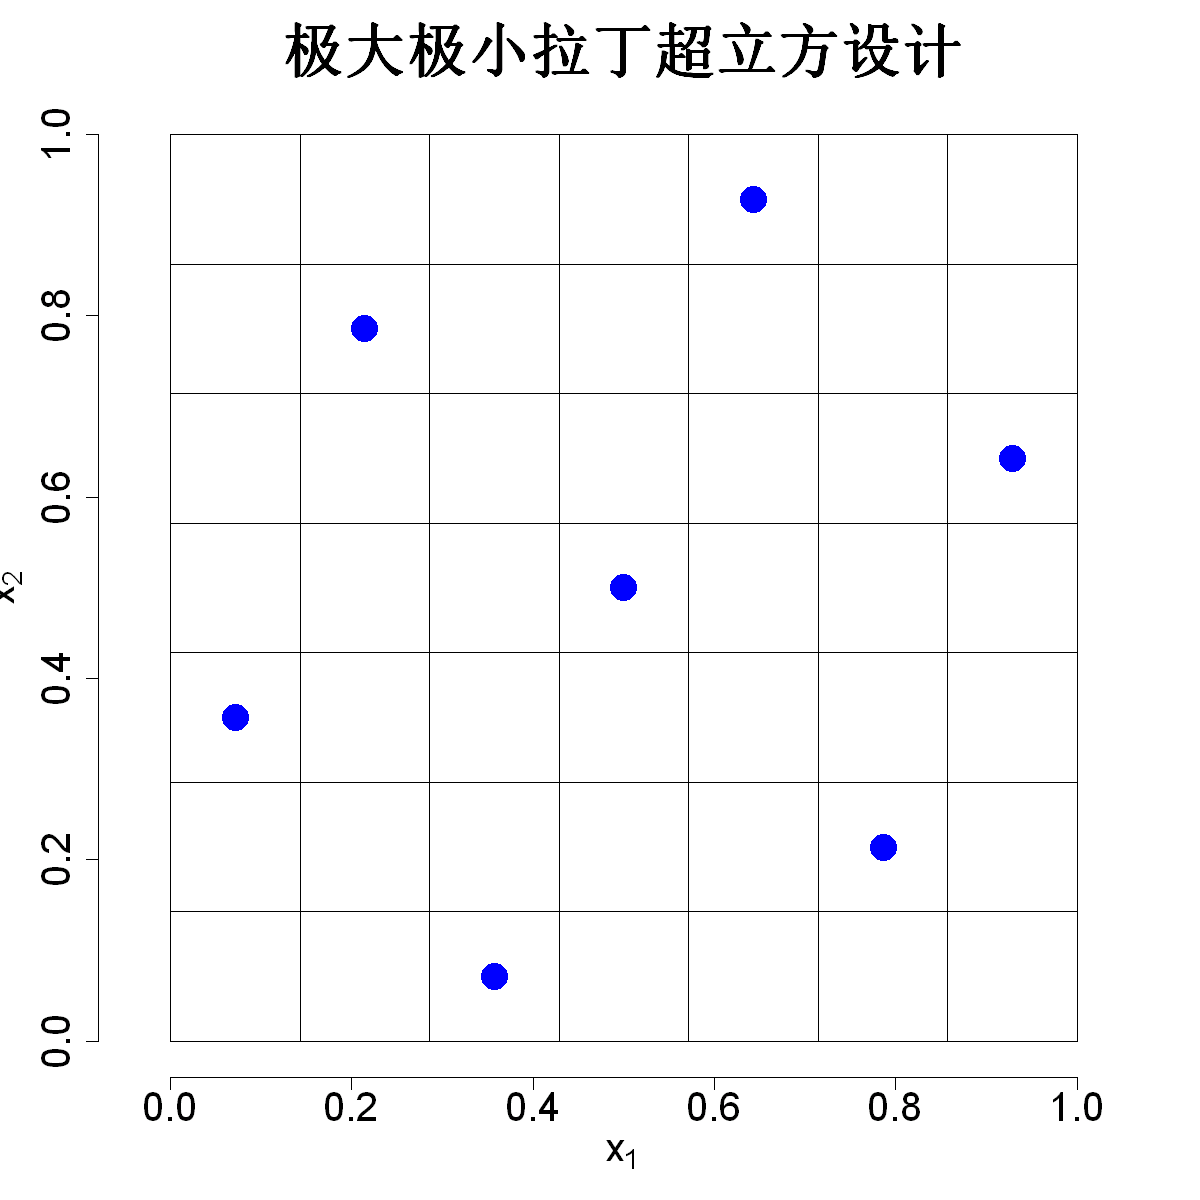

In [5]:
#图4.8

options(repr.plot.width=10,repr.plot.height=10)
p=2;n=7
set.seed(123)
library(SFDesign)
D=maximinLHD(n,p)$design
plot(D,pch=16,cex=3,bty="n",col="blue",xlim=c(0,1),ylim=c(0,1),xlab=expression(x[1]),ylab=expression(x[2]),cex.lab=2,cex.axis=2,main="极大极小拉丁超立方设计",cex.main=3,asp=1)
for(i in 1:(n+1))
{
segments(0,(i-1)/n,1,(i-1)/n)
segments((i-1)/n,0,(i-1)/n,1)
}

学术界已提出多种拉丁超立方设计改进形式.叶(1998)提出正交拉丁超立方设计,该类设计所有列之间相关系数均为0.约瑟夫与亨(2008)将正交性与极大极小准则相结合,构造正交极大极小拉丁超立方设计(OMLHD).若目标为拟合均值包含线性主效应回归项的高斯过程模型,或是盲克里金模型,正交极大极小拉丁超立方设计通常表现优异(约瑟夫等人,2008).可调用R语言程序包`LHD`中的`SA2008`函数生成正交极大极小拉丁超立方设计(王等人,2022).

上述所有拉丁超立方设计均采用式(4.21)中的中心取值形式,使得一维投影构成极小极大设计.德特与佩佩利舍夫(2010)提出在一维投影上采用切比雪夫设计.若将该思路与极大极小拉丁超立方设计相结合,可先构造极大极小拉丁超立方设计,再通过式(2.5)对坐标进行变换:$D_{ij}\leftarrow(1+\cos(\pi D_{ij}))/2$,其中$D$为原始极大极小拉丁超立方设计.图4.9展示了一组20次试验的极大极小拉丁超立方设计,以及经过切比雪夫变换后的极大极小拉丁超立方设计.不难看出,切比雪夫变换会促使采样点向区域边界聚集.该方法与式(4.18)中的总倒数距离准则存在紧密联系.考虑一维情形,即$p=1$,容易推得

$$\lim_{\alpha\to0}\left\{\sum_{i=1}^{n}\sum_{j\ne i}\frac{1}{|x_{i}-x_{j}|^{2\alpha}}\right\}^{1/\alpha}=-\sum_{i=1}^{n}\sum_{j\ne i}\log|x_{i}-x_{j}|$$

等式右侧被称为对数势能.当$n\to\infty$时,最小化对数势能准则对应的设计服从反正弦分布

$$f(x)=\frac{1}{\pi\sqrt{x(1-x)}}$$

(德特与斯图登,1992).$n$点切比雪夫设计能够对该密度实现最优分位数逼近.正如前文图3.3所示,切比雪夫设计在逼近光滑函数时效果优良,但针对非光滑函数表现欠佳.由此可见,经过切比雪夫变换得到的设计,对于相关参数的设定偏差不具备稳健性.

>**图4.9** 左图为20次试验的极大极小拉丁超立方设计,右图为经过切比雪夫变换后的同一组极大极小拉丁超立方设计.

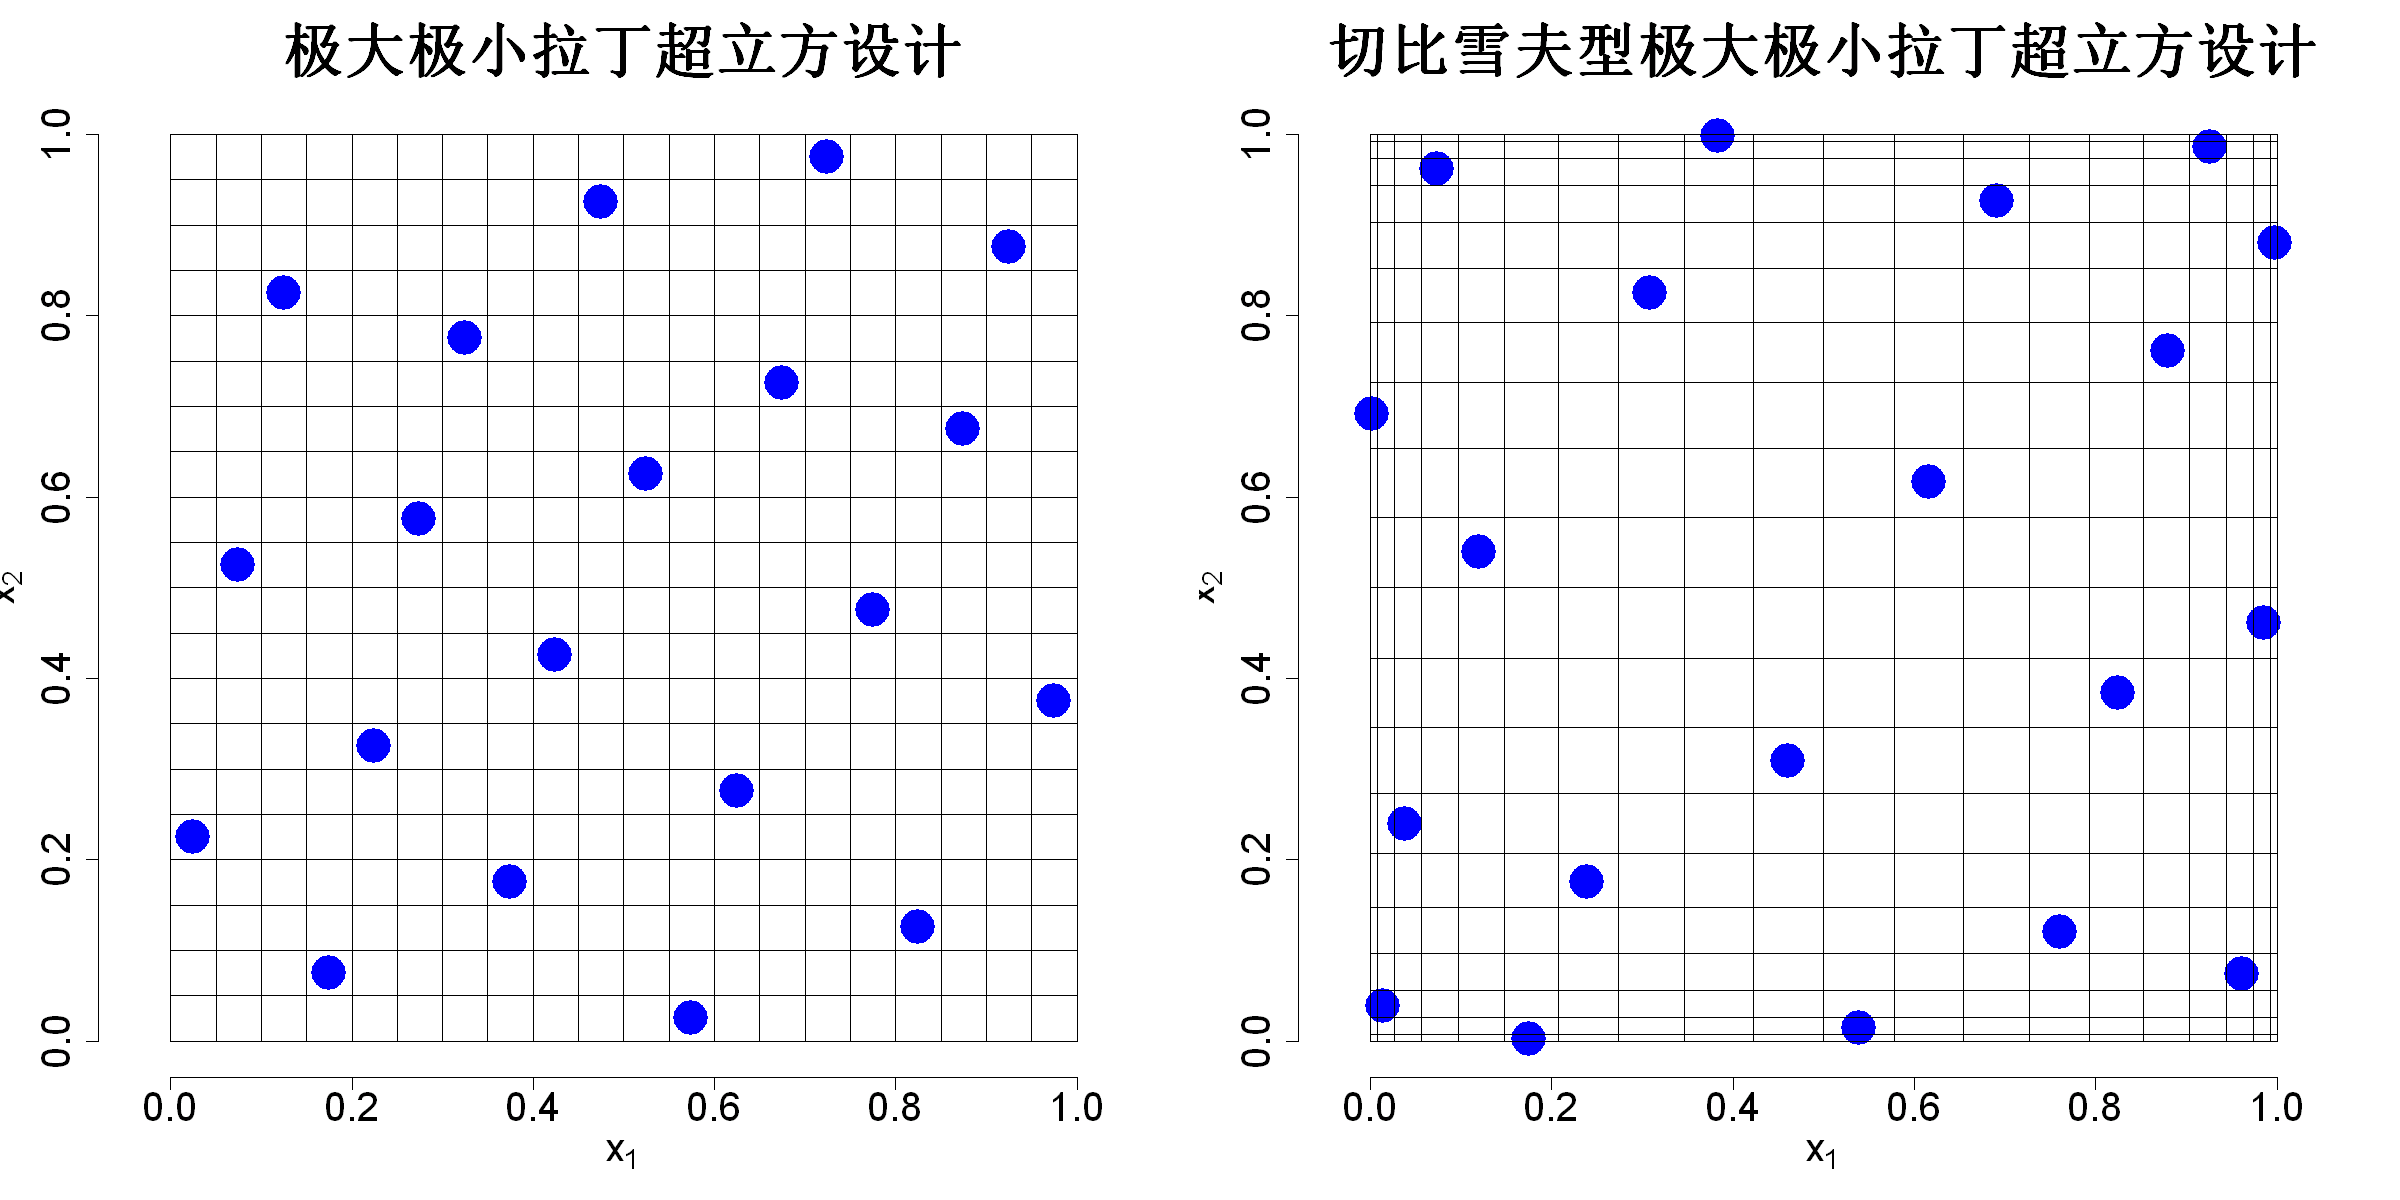

In [3]:
#图4.9

options(repr.plot.width=20,repr.plot.height=10)
par(mfrow=c(1,2))
p=2;n=20
set.seed(1)
library(SFDesign)
D=maximinLHD(n,p)$design
plot(D,pch=16,cex=4,bty="n",col="blue",xlim=c(0,1),ylim=c(0,1),xlab=expression(x[1]),ylab=expression(x[2]),main="极大极小拉丁超立方设计",cex.lab=2,cex.axis=2,cex.main=3,asp=1)
for(i in 1:(n+1))
{
segments((i-1)/n,0,(i-1)/n,1)
segments(0,(i-1)/n,1,(i-1)/n)
}

D1=(1+cos(pi*D))/2
plot(D1,pch=16,cex=4,bty="n",col="blue",xlim=c(0,1),ylim=c(0,1),xlab=expression(x[1]),ylab=expression(x[2]),cex.lab=2,cex.axis=2,main="切比雪夫型极大极小拉丁超立方设计",cex.main=3,asp=1)
d1=sort(D1[,1])
l1=c(0,(d1[-1]+d1[-n])/2,1)
d2=sort(D1[,2])
l2=c(0,(d2[-1]+d2[-n])/2,1)
for(i in 1:(n+1))
{
segments(l1[i],0,l1[i],1)
segments(0,l2[i],1,l2[i])
}
par(mfrow=c(1,1))